# Dilemme choc / vibration

Système masse-ressort-amortisseur à 1 degré de liberté.
Deux paramètres gouvernent le comportement de l'emballage :

$$f_0 = \frac{1}{2\pi}\sqrt{\frac{k}{m}} \qquad \zeta = \frac{c}{2\sqrt{km}}$$

- $f_0$ : fréquence propre — détermine la zone de résonance et l'isolation vibratoire
- $\zeta$ (zeta) : amortissement réduit — contrôle l'amplitude du pic et la durée des oscillations post-choc

Ce notebook comprend :
- trois graphiques séparés (Bode, déplacement, accélération) pour trois configurations types ;
- un graphique interactif pour explorer l'effet de $f_0$ et $\zeta$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams.update({
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Paramètres communs
m     = 1000.0   # masse (kg)
g_std = 9.81     # m/s²
A_choc = 10 * g_std   # amplitude choc : 10 g
T_choc = 11e-3        # durée demi-sinusoïde : 11 ms
t_end  = 0.6
t_eval = np.linspace(0, t_end, 4000)

configs = [
    {'label': 'Souple  ($f_0=2$ Hz)',  'f0': 2,  'zeta': 0.10, 'color': '#E05A2B', 'ls': '-'},
    {'label': 'Médium  ($f_0=5$ Hz)',  'f0': 5,  'zeta': 0.10, 'color': '#2B7BE0', 'ls': '--'},
    {'label': 'Rigide  ($f_0=10$ Hz)', 'f0': 10, 'zeta': 0.10, 'color': '#2BA85A', 'ls': ':'},
]

def a_sol(t):
    return A_choc * np.sin(np.pi * t / T_choc) if 0 <= t <= T_choc else 0.0

def transmissibilite(f, f0, zeta):
    r = f / f0
    return np.sqrt((1 + (2*zeta*r)**2) / ((1 - r**2)**2 + (2*zeta*r)**2))

def reponse_choc(f0, zeta):
    omega0 = 2 * np.pi * f0
    def syst(t, y):
        x, v = y
        return [v, -2*zeta*omega0*v - omega0**2*x + a_sol(t)]
    sol = solve_ivp(syst, [0, t_end], [0, 0], t_eval=t_eval, rtol=1e-9)
    v   = sol.y[1]
    a_arr = np.array([a_sol(t) for t in sol.t])
    a_g   = (a_arr - 2*zeta*omega0*v - omega0**2*sol.y[0]) / g_std
    return sol.t*1000, sol.y[0]*1000, a_g

f_arr = np.logspace(-0.3, np.log10(150), 2000)
print('Fonctions prêtes.')

Fonctions prêtes.


## 1. Diagramme de Bode — transmissibilité

$T(f)$ en dB : au-dessus de 0 dB, la masse vibre plus que le sol (résonance).
La zone grisée représente la bande de sollicitation mesurée en transport (1–120 Hz).

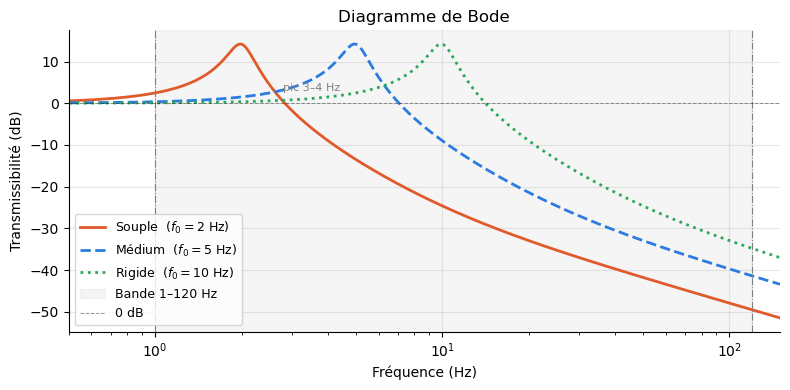

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
for cfg in configs:
    T_dB = 20 * np.log10(transmissibilite(f_arr, cfg['f0'], cfg['zeta']))
    ax.semilogx(f_arr, T_dB, color=cfg['color'], ls=cfg['ls'], lw=2, label=cfg['label'])

ax.axvspan(1, 120, alpha=0.08, color='gray', label='Bande 1–120 Hz')
ax.axvline(1,   color='gray', lw=0.8, ls='-.')
ax.axvline(120, color='gray', lw=0.8, ls='-.')
ax.axhline(0,   color='black', lw=0.7, ls='--', alpha=0.4, label='0 dB')
ax.annotate('pic 3–4 Hz', xy=(3.5, 3), fontsize=8, color='gray', ha='center')
ax.set_xlabel('Fréquence (Hz)')
ax.set_ylabel('Transmissibilité (dB)')
ax.set_title('Diagramme de Bode')
ax.set_xlim(0.5, 150)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 2. Réponse au choc — déplacement

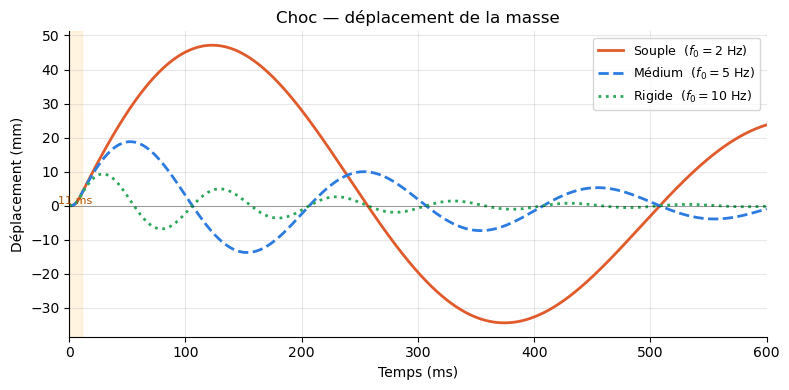

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for cfg in configs:
    t_ms, x_mm, _ = reponse_choc(cfg['f0'], cfg['zeta'])
    ax.plot(t_ms, x_mm, color=cfg['color'], ls=cfg['ls'], lw=2, label=cfg['label'])

ax.axhline(0, color='black', lw=0.6, alpha=0.4)
ax.axvspan(0, T_choc*1000, alpha=0.12, color='orange')
ax.text(T_choc*500, 0, '11 ms', ha='center', va='bottom', fontsize=8, color='#B05000')
ax.set_xlabel('Temps (ms)')
ax.set_ylabel('Déplacement (mm)')
ax.set_title('Choc — déplacement de la masse')
ax.set_xlim(0, t_end*1000)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 3. Réponse au choc — accélération transmise

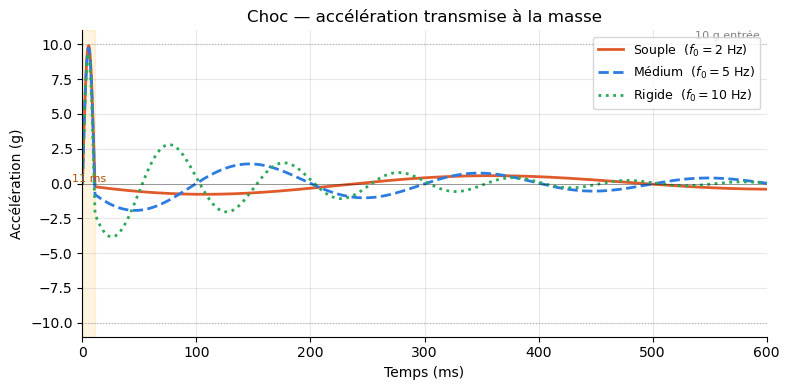

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
for cfg in configs:
    t_ms, _, a_g = reponse_choc(cfg['f0'], cfg['zeta'])
    ax.plot(t_ms, a_g, color=cfg['color'], ls=cfg['ls'], lw=2, label=cfg['label'])

ax.axhline(0,  color='black', lw=0.6, alpha=0.4)
ax.axhline(10, color='gray',  lw=0.8, ls=':', alpha=0.5)
ax.axhline(-10,color='gray',  lw=0.8, ls=':', alpha=0.5)
ax.axvspan(0, T_choc*1000, alpha=0.12, color='orange')
ax.text(T_choc*500, 0, '11 ms', ha='center', va='bottom', fontsize=8, color='#B05000')
ax.text(t_end*990, 10.4, '10 g entrée', ha='right', fontsize=8, color='gray')
ax.set_xlabel('Temps (ms)')
ax.set_ylabel('Accélération (g)')
ax.set_title('Choc — accélération transmise à la masse')
ax.set_xlim(0, t_end*1000)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Exploration interactive — effet de $f_0$ et $\zeta$

Modifiez les curseurs pour observer l'influence de la fréquence propre et de l'amortissement sur les trois critères simultanément.

In [5]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    def tracer(f0=5.0, zeta=0.10):
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        ax1, ax2, ax3 = axes
        fig.subplots_adjust(wspace=0.38)

        # Références en gris
        for cfg in configs:
            T_dB = 20 * np.log10(transmissibilite(f_arr, cfg['f0'], cfg['zeta']))
            ax1.semilogx(f_arr, T_dB, color='lightgray', ls=cfg['ls'], lw=1.5)
            t_ms, x_mm, a_g = reponse_choc(cfg['f0'], cfg['zeta'])
            ax2.plot(t_ms, x_mm, color='lightgray', ls=cfg['ls'], lw=1.5)
            ax3.plot(t_ms, a_g,  color='lightgray', ls=cfg['ls'], lw=1.5)

        # Courbe interactive en rouge
        label = f'$f_0={f0}$ Hz, $\\zeta={zeta}$'
        T_dB = 20 * np.log10(transmissibilite(f_arr, f0, zeta))
        ax1.semilogx(f_arr, T_dB, 'r-', lw=2.5, label=label)
        t_ms, x_mm, a_g = reponse_choc(f0, zeta)
        ax2.plot(t_ms, x_mm, 'r-', lw=2.5, label=label)
        ax3.plot(t_ms, a_g,  'r-', lw=2.5, label=label)

        ax1.axvspan(1, 120, alpha=0.08, color='gray')
        ax1.axhline(0, color='black', lw=0.7, ls='--', alpha=0.4)
        ax1.set_xlabel('Fréquence (Hz)'); ax1.set_ylabel('Transmissibilité (dB)')
        ax1.set_title('Bode'); ax1.set_xlim(0.5, 150); ax1.legend(fontsize=9)

        for ax in (ax2, ax3):
            ax.axhline(0, color='black', lw=0.6, alpha=0.4)
            ax.axvspan(0, T_choc*1000, alpha=0.10, color='orange')
            ax.set_xlabel('Temps (ms)'); ax.set_xlim(0, t_end*1000)
            ax.legend(fontsize=9)
        ax2.set_ylabel('Déplacement (mm)'); ax2.set_title('Choc — déplacement')
        ax3.axhline(10, color='gray', lw=0.8, ls=':', alpha=0.5)
        ax3.axhline(-10, color='gray', lw=0.8, ls=':', alpha=0.5)
        ax3.set_ylabel('Accélération (g)'); ax3.set_title('Choc — accélération')

        plt.suptitle(f'Exploration : $f_0 = {f0}$ Hz, $\\zeta = {zeta}$', y=1.02)
        plt.show()

    widgets.interact(
        tracer,
        f0   = widgets.FloatSlider(value=5.0, min=0.5, max=15.0, step=0.5,
                                   description='f₀ (Hz)', style={'description_width': '80px'}),
        zeta = widgets.FloatSlider(value=0.10, min=0.01, max=0.50, step=0.01,
                                   description='ζ (zeta)', style={'description_width': '80px'}),
    )

except ImportError:
    print("ipywidgets non disponible (environnement Basthon) — affichage statique")
    for f0, zeta, color in [(3.0, 0.10, 'steelblue'), (5.0, 0.10, 'red'), (8.0, 0.25, 'green')]:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        ax1, ax2, ax3 = axes
        fig.subplots_adjust(wspace=0.38)
        label = f'f₀={f0} Hz, ζ={zeta}'
        T_dB = 20 * np.log10(transmissibilite(f_arr, f0, zeta))
        ax1.semilogx(f_arr, T_dB, color=color, lw=2.5, label=label)
        t_ms, x_mm, a_g = reponse_choc(f0, zeta)
        ax2.plot(t_ms, x_mm, color=color, lw=2.5, label=label)
        ax3.plot(t_ms, a_g,  color=color, lw=2.5, label=label)
        ax1.axvspan(1, 120, alpha=0.08, color='gray')
        ax1.axhline(0, color='black', lw=0.7, ls='--', alpha=0.4)
        ax1.set_xlabel('Fréquence (Hz)'); ax1.set_ylabel('Transmissibilité (dB)')
        ax1.set_title('Bode'); ax1.set_xlim(0.5, 150); ax1.legend(fontsize=9)
        for ax in (ax2, ax3):
            ax.axhline(0, color='black', lw=0.6, alpha=0.4)
            ax.axvspan(0, T_choc*1000, alpha=0.10, color='orange')
            ax.set_xlabel('Temps (ms)'); ax.set_xlim(0, t_end*1000)
            ax.legend(fontsize=9)
        ax2.set_ylabel('Déplacement (mm)'); ax2.set_title('Choc — déplacement')
        ax3.axhline(10, color='gray', lw=0.8, ls=':', alpha=0.5)
        ax3.axhline(-10, color='gray', lw=0.8, ls=':', alpha=0.5)
        ax3.set_ylabel('Accélération (g)'); ax3.set_title('Choc — accélération')
        plt.suptitle(f'Exploration statique : f₀={f0} Hz, ζ={zeta}', y=1.02)
        plt.show()


interactive(children=(FloatSlider(value=5.0, description='f₀ (Hz)', max=15.0, min=0.5, step=0.5, style=SliderS…